# HIGGS: symmetries, topology and equivariant models

In [1]:
# Core dependencies (quiet no-ops if already installed)
!pip install -q pandas numpy matplotlib seaborn scipy scikit-learn lightgbm
!pip install -q ripser persim
!pip install -q torch egnn_pytorch
!pip install -q gudhi

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 843.4/843.4 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 57.5 MB/s eta 0:00:00


In [2]:
import os
import time
import urllib.request
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import gudhi as gd
import ripser
from persim import plot_diagrams, bottleneck
from persim.persistent_entropy import persistent_entropy

from scipy.spatial import KDTree

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")

PyTorch version: 2.11.0+cu128
Using device: cuda


# Download and load

Download may stop for no reason, restart it. Before restarting delete the partially downloaded file

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00280/HIGGS.csv.gz"
filename = "HIGGS.csv.gz"

def report_progress(block_num, block_size, total_size):
    downloaded = block_num * block_size
    if total_size > 0:
        percent = min(100, downloaded * 100 / total_size)
        print(f"\rDownloaded: {downloaded / (1024**2):.1f} MB of {total_size / (1024**2):.1f} MB ({percent:.1f}%)", end='')
    else:
        print(f"\rDownloaded: {downloaded / (1024**2):.1f} MB", end='')
    if downloaded >= total_size > 0:
        print()

if not os.path.exists(filename):
    print("Downloading HIGGS dataset (2.6 GB)... This may take a few minutes.")
    urllib.request.urlretrieve(url, filename, reporthook=report_progress)
    print("Download complete.")
else:
    print("Dataset already exists locally.")

# 1 label column + 21 low-level features + 7 high-level features = 29 columns
columns = ["label"] + [
    "lepton_pT", "lepton_eta", "lepton_phi", "missing_energy_magnitude", "missing_energy_phi",
    "jet1_pt", "jet1_eta", "jet1_phi", "jet1_b-tag",
    "jet2_pt", "jet2_eta", "jet2_phi", "jet2_b-tag",
    "jet3_pt", "jet3_eta", "jet3_phi", "jet3_b-tag",
    "jet4_pt", "jet4_eta", "jet4_phi", "jet4_b-tag",
    "m_jj", "m_jjj", "m_lv", "m_jlv", "m_bb", "m_wbb", "m_wwbb"
]

# 200k rows are used throughout (100k for EDA, 200k for training).
# Remove nrows to use the full 11M-row dataset.
N_ROWS = 200_000
print("Loading dataset...")
df_full = pd.read_csv(filename, compression='gzip', header=None, names=columns, nrows=N_ROWS)
df = df_full.head(100_000)  # EDA subset
print(f"Loaded {len(df_full):,} rows ({len(df):,} used for EDA), {len(df_full.columns)} columns.")
df.head()

Downloaded: 2685.9 MBDownload complete.
Loading dataset...
Loaded 200,000 rows (100,000 used for EDA), 29 columns.


,label,lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet1_pt,jet1_eta,jet1_phi,jet1_b-tag,...,jet4_eta,jet4_phi,jet4_b-tag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
0,1.0,0.869293,-0.635082,0.225690,0.327470,-0.689993,0.754202,-0.248573,-1.092064,0.000000,...,-0.010455,-0.045767,3.101961,1.353760,0.979563,0.978076,0.920005,0.721657,0.988751,0.876678
1,1.0,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
2,1.0,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
3,0.0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
4,1.0,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487


## Dataset units

The UCI HIGGS features are **not raw physical quantities**. Following Baldi, Sadowski &
Whiteson (Nature Comm. 2014), features with signed values (η, φ) were standardized to
mean 0 / std 1, and strictly-positive features (pT, masses, MET) were scaled to mean 1.

Consequence for angles: raw φ is uniform on [−π, π] with std σ_φ = π/√3 ≈ 1.8138, so the
standardized φ columns span exactly ±√3 ≈ ±1.732. We verify this below and define the
conversion constant used everywhere angular arithmetic is needed.

For η and pT the original scale factors were not published and **cannot be recovered**,
so η-shifts below are expressed in σ-units (units of the feature's standard deviation)
and pT is treated as a dimensionless scale variable.

In [4]:
PHI_SIGMA = np.pi / np.sqrt(3)   # std of Uniform(-pi, pi); converts standardized phi -> radians

phi_cols = [c for c in df.columns if 'phi' in c]
eta_cols = [c for c in df.columns if 'eta' in c and 'phi' not in c]

print("phi columns:", phi_cols)
print(f"max |phi_std| over data:  {df_full[phi_cols].abs().max().max():.4f}")
print(f"sqrt(3) =                 {np.sqrt(3):.4f}")
print(f"phi std:                  {df_full[phi_cols].std().mean():.4f}")
print(f"eta std:                  {df_full[eta_cols].std().mean():.4f}  (standardized)")
print(f"lepton_pT mean:           {df_full['lepton_pT'].mean():.4f}  (scaled to mean 1)")

assert df_full[phi_cols].abs().max().max() < np.sqrt(3) + 0.05, "phi columns do not look standardized"

def phi_std_to_rad(phi_std):
    return phi_std * PHI_SIGMA

def phi_rad_to_std(phi_rad):
    return phi_rad / PHI_SIGMA

phi columns: ['lepton_phi', 'missing_energy_phi', 'jet1_phi', 'jet2_phi', 'jet3_phi', 'jet4_phi']
max |phi_std| over data:  1.7439
sqrt(3) =                 1.7321
phi std:                  1.0065
eta std:                  1.0082  (standardized)
lepton_pT mean:           0.9915  (scaled to mean 1)


# EDA

--- Missing values (max over columns) ---
0

--- Class distribution ---
label
1.0    52834
0.0    47166
Name: count, dtype: int64


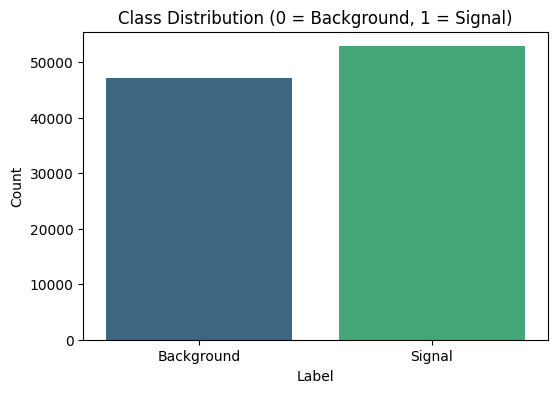

,label,lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet1_pt,jet1_eta,jet1_phi,jet1_b-tag,...,jet4_eta,jet4_phi,jet4_b-tag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,...,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,0.53,0.99,-0.00,-0.00,1.00,-0.01,0.99,-0.00,0.00,1.00,...,-0.01,-0.00,0.99,1.03,1.02,1.05,1.01,0.97,1.03,0.96
std,0.50,0.56,1.00,1.01,0.60,1.01,0.47,1.01,1.01,1.03,...,1.01,1.01,1.40,0.65,0.37,0.16,0.40,0.52,0.36,0.31
min,0.00,0.27,-2.43,-1.74,0.00,-1.74,0.14,-2.97,-1.74,0.00,...,-2.50,-1.74,0.00,0.11,0.30,0.13,0.30,0.05,0.30,0.35
25%,0.00,0.59,-0.74,-0.87,0.58,-0.88,0.68,-0.69,-0.87,0.00,...,-0.73,-0.88,0.00,0.79,0.85,0.99,0.77,0.67,0.82,0.77
50%,1.00,0.85,-0.00,0.00,0.89,-0.01,0.89,-0.00,-0.00,1.09,...,-0.01,-0.01,0.00,0.90,0.95,0.99,0.92,0.87,0.95,0.87
75%,1.00,1.24,0.74,0.87,1.29,0.87,1.17,0.68,0.87,2.17,...,0.71,0.87,3.10,1.03,1.08,1.02,1.14,1.14,1.14,1.06
max,1.00,7.81,2.43,1.74,8.00,1.74,7.06,2.97,1.74,2.17,...,2.50,1.74,3.10,18.43,10.04,4.57,7.44,11.99,7.32,6.02


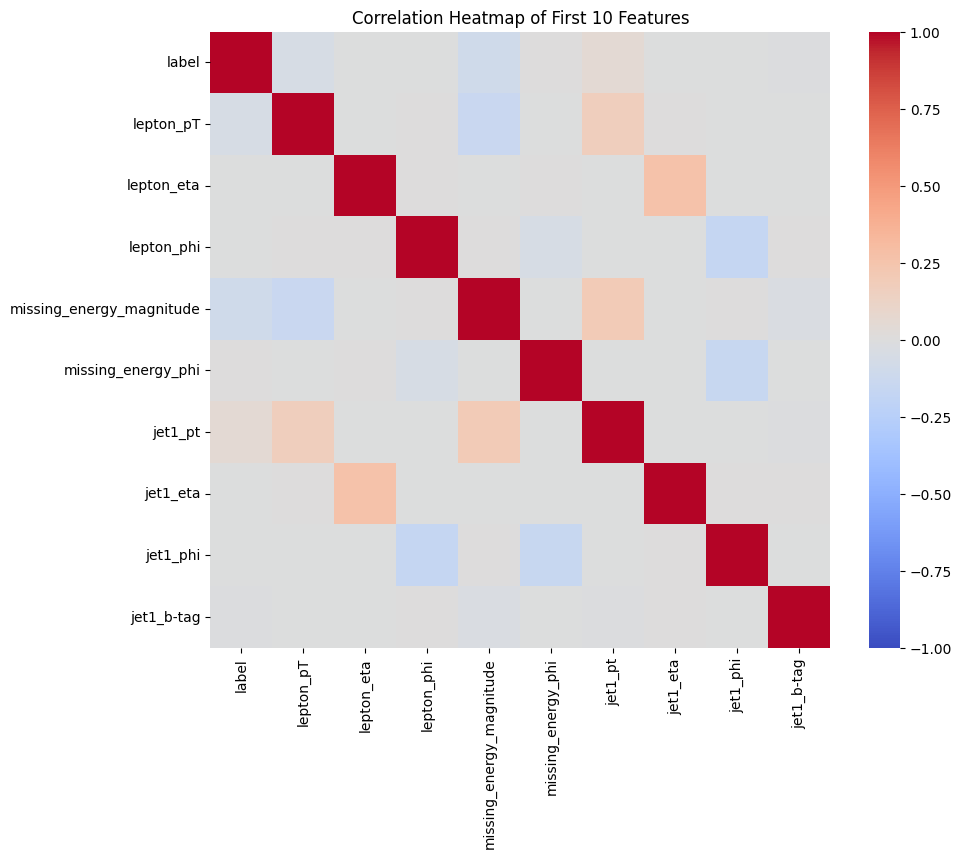

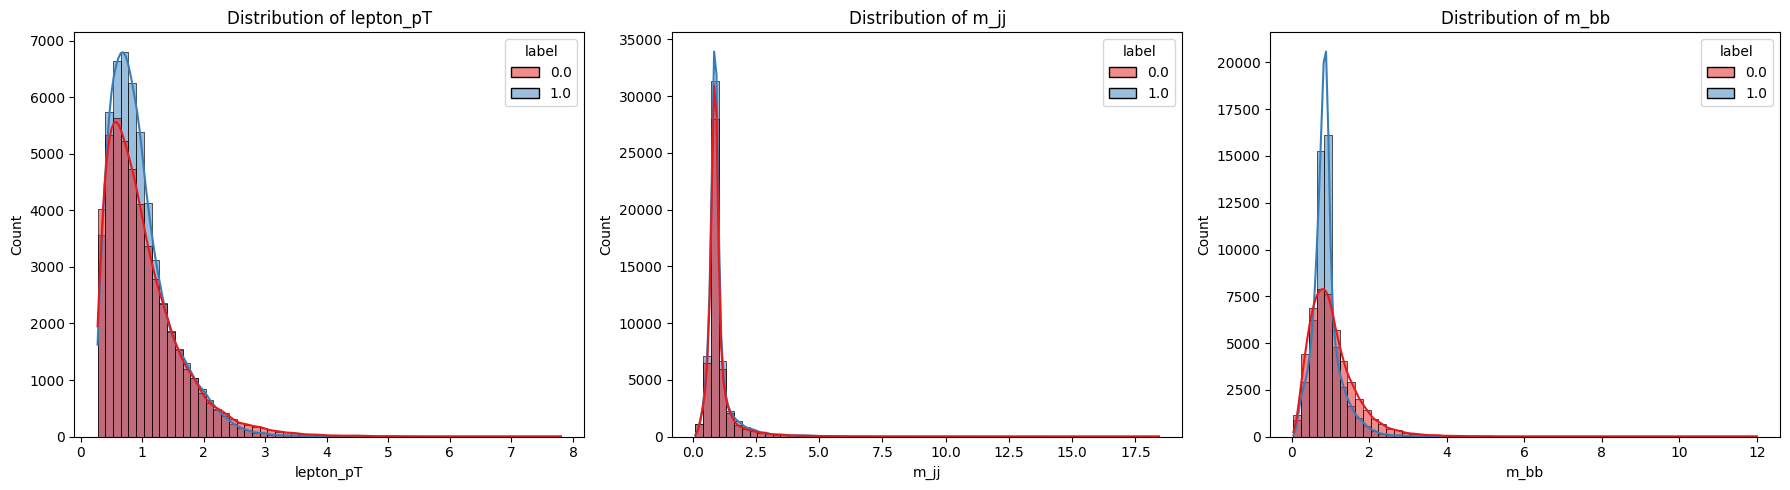

In [5]:
print("--- Missing values (max over columns) ---")
print(df.isnull().sum().max())  # 0 for this dataset

print("\n--- Class distribution ---")
print(df['label'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, hue='label', palette='viridis', legend=False)
plt.title('Class Distribution (0 = Background, 1 = Signal)')
plt.xlabel('Label'); plt.ylabel('Count')
plt.xticks([0, 1], ['Background', 'Signal'])
plt.show()

display(df.describe().round(2))

plt.figure(figsize=(10, 8))
sns.heatmap(df.iloc[:, :10].corr(), annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of First 10 Features')
plt.show()

features_to_plot = ['lepton_pT', 'm_jj', 'm_bb']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(features_to_plot):
    sns.histplot(data=df, x=feat, hue='label', bins=60, ax=axes[i], kde=True, palette='Set1')
    axes[i].set_title(f'Distribution of {feat}')
plt.tight_layout()
plt.show()

## Quick topological look at the feature space

Exploratory only: 500 points in 28 dimensions is far too sparse to estimate the true
topology of the data manifold; the diagrams mostly reflect sampling noise and the
ambient dimension. Rips complexes also scale between O(N^2) and O(N^3), hence the small
subsample.

Computing Rips persistence diagram on 500 points (standardised)...


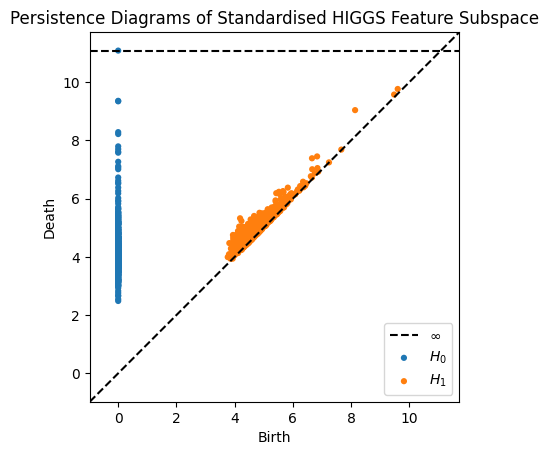

In [6]:
import ripser
from persim import plot_diagrams
from sklearn.preprocessing import StandardScaler

sample_size = 500
tda_features = df.drop(columns=['label']).sample(n=sample_size, random_state=42).values
tda_features_scaled = StandardScaler().fit_transform(tda_features)

print(f"Computing Rips persistence diagram on {sample_size} points (standardised)...")
diagrams = ripser.ripser(tda_features_scaled, maxdim=1)['dgms']
plot_diagrams(diagrams, show=True, title="Persistence Diagrams of Standardised HIGGS Feature Subspace")

## From kinematic features to 3D "pseudo-momenta"

To use rotation-equivariant models we embed each event's 4 jets as points in 3D via
(pT, η, φ) → (pT·cos φ, pT·sin φ, pT·sinh η), **converting the standardized φ back to
radians first** so the azimuthal coverage is the full circle.

Caveats (these coordinates are *pseudo*-momenta, not physical momenta):
- pT is in the dataset's dimensionless scale (mean ≈ 1), not GeV;
- η is in σ-units, so sinh(η_std) distorts the longitudinal component by an unknown
  monotone rescaling;
- momentum space has no translation symmetry, and the beam axis breaks full O(3)
  down to rotations about z (plus reflections). Any model imposing more symmetry than
  that (e.g. an E(3)-equivariant network) is imposing symmetry the physics does not have.

In [7]:
def kinematic_to_cartesian(pt, eta_std, phi_std):
    """Standardized (pt, eta, phi) -> 3D pseudo-momentum (x, y, z).

    phi is converted to radians (phi_std * pi/sqrt(3)); eta stays in sigma-units,
    so z is only a monotone proxy for the true longitudinal momentum.
    """
    phi = phi_std_to_rad(phi_std)
    x = pt * np.cos(phi)
    y = pt * np.sin(phi)
    z = pt * np.sinh(eta_std)
    return np.stack([x, y, z], axis=-1)

# Demo on a single event: 4 jets as a small point cloud
row = df.iloc[0]
jet_pts  = row[['jet1_pt', 'jet2_pt', 'jet3_pt', 'jet4_pt']].values.astype(float)
jet_etas = row[['jet1_eta', 'jet2_eta', 'jet3_eta', 'jet4_eta']].values.astype(float)
jet_phis = row[['jet1_phi', 'jet2_phi', 'jet3_phi', 'jet4_phi']].values.astype(float)

coords = kinematic_to_cartesian(jet_pts, jet_etas, jet_phis)
btags  = row[['jet1_b-tag', 'jet2_b-tag', 'jet3_b-tag', 'jet4_b-tag']].values.astype(float)

print("Jet pseudo-momenta (4, 3):\n", np.round(coords, 3))
print("b-tags:", btags)

Jet pseudo-momenta (4, 3):
 [[-0.301 -0.692 -0.189]
 [-0.16   1.366 -0.964]
 [-0.367 -1.078 -2.642]
 [ 0.656 -0.055 -0.007]]
b-tags: [0.         1.10743606 0.         3.10196137]


# Baselines

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

# Split ONCE, as indices, and reuse everywhere (baselines, symmetry tests, EGNN).
# This removes the earlier fragile pattern of two separate train_test_split calls
# that only happened to produce identical splits.
X = df_full.drop(columns=['label']).values
y = df_full['label'].values
feature_names = df_full.drop(columns=['label']).columns.tolist()

idx_train, idx_test = train_test_split(
    np.arange(len(df_full)), test_size=0.2, random_state=42, stratify=y
)
X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

# Scaling for LR / MLP (fit on train only). Tree models get unscaled data.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}, test set: {X_test.shape}")

Training set: (160000, 28), test set: (40000, 28)


In [9]:
from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression...")
start_time = time.time()
lr_model = LogisticRegression(solver='saga', max_iter=500, random_state=42, n_jobs=-1)
lr_model.fit(X_train_scaled, y_train)
print(f"Training time: {time.time() - start_time:.2f}s")

y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = (y_prob_lr > 0.5).astype(int)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Test ROC-AUC:  {roc_auc_score(y_test, y_prob_lr):.4f}")

Training Logistic Regression...
Training time: 1.19s
Test Accuracy: 0.6406
Test ROC-AUC:  0.6828


In [10]:
import lightgbm as lgb

print("Training LightGBM...")
start_time = time.time()
lgb_model = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=8, num_leaves=31,
    random_state=42, n_jobs=-1, verbose=-1
)
# Unscaled data: tree splits are invariant to monotonic transformations
lgb_model.fit(X_train, y_train)
print(f"Training time: {time.time() - start_time:.2f}s")

y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]
y_pred_lgb = (y_prob_lgb > 0.5).astype(int)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_lgb):.4f}")
print(f"Test ROC-AUC:  {roc_auc_score(y_test, y_prob_lgb):.4f}")

Training LightGBM...
Training time: 6.96s
Test Accuracy: 0.7275
Test ROC-AUC:  0.8078


In [11]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
)
test_dataset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1)  # logits; BCEWithLogitsLoss applies the sigmoid
        )
    def forward(self, x):
        return self.network(x)

torch.manual_seed(42)
model = SimpleMLP(input_dim=X_train_scaled.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Training PyTorch MLP...")
epochs = 10
start_time = time.time()
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(batch_X), batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 2 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.4f}")
print(f"Total training time: {time.time() - start_time:.2f}s")

model.eval()
probs = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        probs.append(torch.sigmoid(model(batch_X.to(device))).cpu().numpy())
y_prob_mlp = np.concatenate(probs).ravel()
y_pred_mlp = (y_prob_mlp > 0.5).astype(int)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"Test ROC-AUC:  {roc_auc_score(y_test, y_prob_mlp):.4f}")

Training PyTorch MLP...
Epoch [2/10], Loss: 0.6100
Epoch [4/10], Loss: 0.5818
Epoch [6/10], Loss: 0.5684
Epoch [8/10], Loss: 0.5589
Epoch [10/10], Loss: 0.5538
Total training time: 16.49s
Test Accuracy: 0.7231
Test ROC-AUC:  0.7996


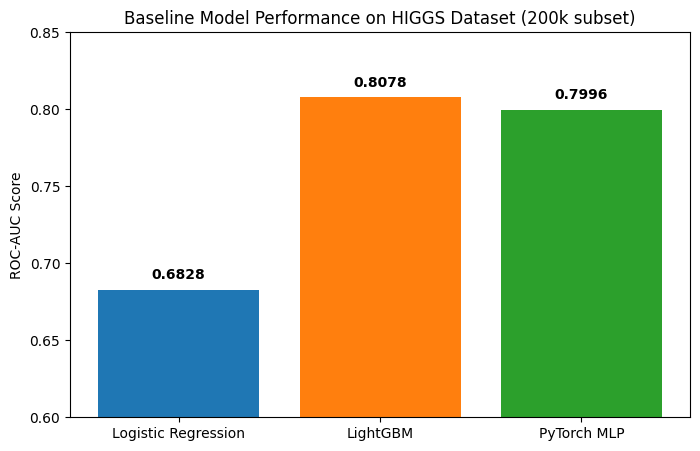

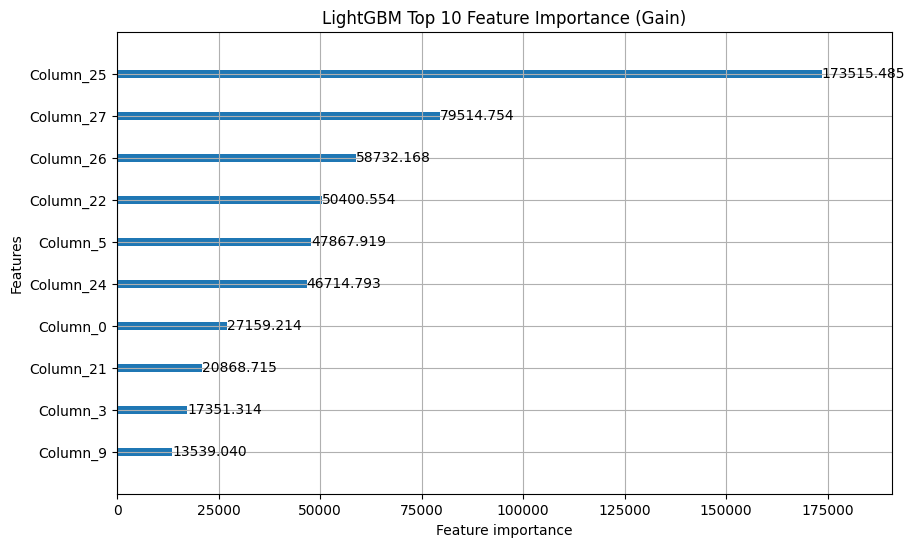

In [12]:
models = ['Logistic Regression', 'LightGBM', 'PyTorch MLP']
auc_scores = [
    roc_auc_score(y_test, y_prob_lr),
    roc_auc_score(y_test, y_prob_lgb),
    roc_auc_score(y_test, y_prob_mlp)
]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, auc_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylim(0.60, 0.85)
plt.ylabel('ROC-AUC Score')
plt.title('Baseline Model Performance on HIGGS Dataset (200k subset)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}',
             ha='center', va='bottom', fontweight='bold')
plt.show()

# LightGBM feature importance by GAIN (explicitly, since the
# feature_importances_ attribute defaults to split counts)
lgb.plot_importance(lgb_model, max_num_features=10, importance_type='gain', figsize=(10, 6))
plt.title('LightGBM Top 10 Feature Importance (Gain)')
plt.show()

# Looking for symmetries

The physical symmetry of a collider event is a **global** azimuthal rotation about the
beam axis: all φ features shift together by the same angle. Because the dataset's φ
columns are standardized, a correct rotation must (1) convert to radians, (2) add Δφ,
(3) wrap to [−π, π], (4) convert back. Done this way the transformed values live on the
same support ±√3 as the originals — the test measures symmetry, not out-of-distribution
robustness.

In [13]:
# Feature indices in the 28-column feature array (label removed):
# 0:lep_pT 1:lep_eta 2:lep_phi 3:met_mag 4:met_phi
# 5:j1_pt 6:j1_eta 7:j1_phi 8:j1_btag | 9..12: jet2 | 13..16: jet3 | 17..20: jet4
# 21..27: m_jj, m_jjj, m_lv, m_jlv, m_bb, m_wbb, m_wwbb
PHI_IDX = [2, 4, 7, 11, 15, 19]
ETA_IDX = [1, 6, 10, 14, 18]
JET_BLOCKS = [[5, 6, 7, 8], [9, 10, 11, 12], [13, 14, 15, 16], [17, 18, 19, 20]]

def rotate_azimuthal(X, delta_phi_rad):
    """Global azimuthal rotation by delta_phi_rad (radians), correct for standardized phi.

    Un-standardize -> rotate -> wrap to [-pi, pi] -> re-standardize.
    The result has the same support (+-sqrt(3)) as the original data.
    """
    X_rot = X.copy()
    phi_rad = phi_std_to_rad(X_rot[:, PHI_IDX]) + delta_phi_rad
    phi_rad = (phi_rad + np.pi) % (2 * np.pi) - np.pi
    X_rot[:, PHI_IDX] = phi_rad_to_std(phi_rad)
    return X_rot

def reverse_jet_order(X):
    """Reverse the 4 pT-ordered jets (jet 4 <-> jet 1, jet 3 <-> jet 2).

    The labeling function is permutation invariant, but the dataset always presents
    jets sorted by pT, so reversed events are out-of-distribution for models that
    learned the 'jet 1 is leading' heuristic. This is a diagnostic of that reliance.
    """
    X_rev = X.copy()
    X_rev[:, JET_BLOCKS[0]] = X[:, JET_BLOCKS[3]]
    X_rev[:, JET_BLOCKS[1]] = X[:, JET_BLOCKS[2]]
    X_rev[:, JET_BLOCKS[2]] = X[:, JET_BLOCKS[1]]
    X_rev[:, JET_BLOCKS[3]] = X[:, JET_BLOCKS[0]]
    return X_rev

def shift_eta_sigma(X, delta_eta_sigma):
    """Shift all eta features by a constant, in sigma-units (the dataset's eta scale).

    This is a heuristic perturbation loosely motivated by a longitudinal boost.
    It is NOT a Lorentz boost, for three separate reasons:
    - the eta columns are standardized, and the raw scale is unrecoverable, so the
      shift is in units of the feature std, not units of pseudorapidity;
    - even in raw units, a rapidity shift equals an eta shift only for massless
      particles; jets are massive;
    - a true boost would also require consistency checks on derived quantities.
    Use only as a robustness probe, not as a Lorentz-invariance test.
    """
    X_shift = X.copy()
    X_shift[:, ETA_IDX] += delta_eta_sigma
    return X_shift

DELTA_ETA_SIGMA = 0.5  # one consistent value, in sigma-units, used everywhere below
print(f"Eta-shift used in robustness probes: {DELTA_ETA_SIGMA} sigma-units")

Eta-shift used in robustness probes: 0.5 sigma-units


In [14]:
# --- MLP robustness under the corrected transformations ---
n_eval = 10_000
X_eval = X_test[:n_eval]
y_eval = y_test[:n_eval]

model.eval()

def mlp_probs_for(X_raw):
    with torch.no_grad():
        t = torch.tensor(scaler.transform(X_raw), dtype=torch.float32).to(device)
        return torch.sigmoid(model(t)).cpu().numpy().ravel()

base_probs = mlp_probs_for(X_eval)
rotated_probs = mlp_probs_for(rotate_azimuthal(X_eval, np.pi / 2))
reversed_probs = mlp_probs_for(reverse_jet_order(X_eval))

print("=" * 55)
print("SYMMETRY ROBUSTNESS TESTS (MLP baseline)")
print("=" * 55)
phi_diff = np.abs(base_probs - rotated_probs)
print("1. Azimuthal rotation (true rotation, dphi = 90 deg):")
print(f"   Mean |dp|: {np.mean(phi_diff):.6f}   Max |dp|: {np.max(phi_diff):.6f}")
print(f"   ROC-AUC original: {roc_auc_score(y_eval, base_probs):.4f}")
print(f"   ROC-AUC rotated:  {roc_auc_score(y_eval, rotated_probs):.4f}")
print("-" * 55)
perm_diff = np.abs(base_probs - reversed_probs)
print("2. Jet order reversal (OOD diagnostic, not an exact-symmetry test):")
print(f"   Mean |dp|: {np.mean(perm_diff):.6f}   Max |dp|: {np.max(perm_diff):.6f}")
print(f"   ROC-AUC original: {roc_auc_score(y_eval, base_probs):.4f}")
print(f"   ROC-AUC reversed: {roc_auc_score(y_eval, reversed_probs):.4f}")
print("=" * 55)

SYMMETRY ROBUSTNESS TESTS (MLP baseline)
1. Azimuthal rotation (true rotation, dphi = 90 deg):
   Mean |dp|: 0.020032   Max |dp|: 0.160801
   ROC-AUC original: 0.8034
   ROC-AUC rotated:  0.8033
-------------------------------------------------------
2. Jet order reversal (OOD diagnostic, not an exact-symmetry test):
   Mean |dp|: 0.094317   Max |dp|: 0.725940
   ROC-AUC original: 0.8034
   ROC-AUC reversed: 0.7622


In [15]:
# --- Eta-shift robustness probe (NOT a Lorentz-boost test; see shift_eta_sigma docstring) ---
X_test_shifted = shift_eta_sigma(X_test, DELTA_ETA_SIGMA)

lgb_probs_base = lgb_model.predict_proba(X_test)[:, 1]
lgb_probs_shift = lgb_model.predict_proba(X_test_shifted)[:, 1]

mlp_probs_base = mlp_probs_for(X_test)
mlp_probs_shift = mlp_probs_for(X_test_shifted)

print("=" * 60)
print(f"ETA-SHIFT ROBUSTNESS PROBE (delta_eta = {DELTA_ETA_SIGMA} sigma-units)")
print("=" * 60)
for name, p_base, p_shift in [("LightGBM", lgb_probs_base, lgb_probs_shift),
                              ("Standard MLP", mlp_probs_base, mlp_probs_shift)]:
    diff = np.abs(p_base - p_shift)
    print(f"{name}:")
    print(f"  Mean |dp|: {np.mean(diff):.6f}   Max |dp|: {np.max(diff):.6f}")
    print(f"  ROC-AUC base:    {roc_auc_score(y_test, p_base):.4f}")
    print(f"  ROC-AUC shifted: {roc_auc_score(y_test, p_shift):.4f}")
    print("-" * 60)

ETA-SHIFT ROBUSTNESS PROBE (delta_eta = 0.5 sigma-units)
LightGBM:
  Mean |dp|: 0.008351   Max |dp|: 0.290834
  ROC-AUC base:    0.8078
  ROC-AUC shifted: 0.8073
------------------------------------------------------------
Standard MLP:
  Mean |dp|: 0.008092   Max |dp|: 0.056790
  ROC-AUC base:    0.7996
  ROC-AUC shifted: 0.7989
------------------------------------------------------------


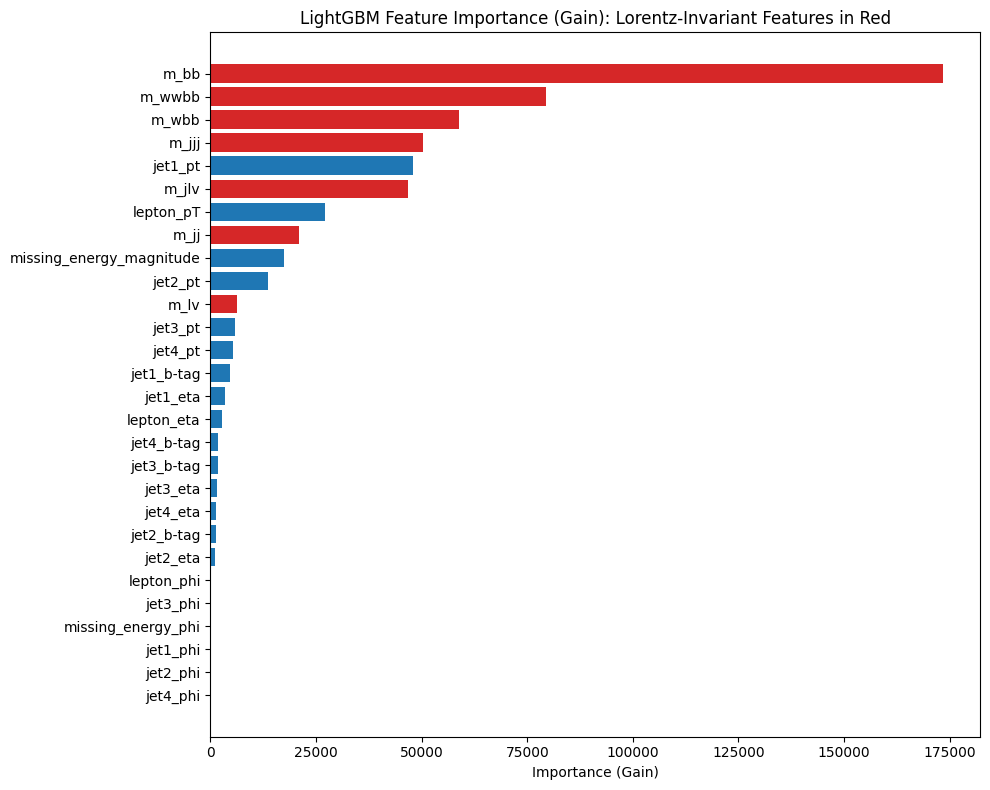

Top 5 most important features (by gain):
Feature    Importance
jet1_pt  47867.918668
  m_jjj  50400.553682
  m_wbb  58732.167541
 m_wwbb  79514.754347
   m_bb 173515.484552


In [16]:
# The 7 high-level features are Lorentz scalars (invariant masses).
high_level_features = ["m_jj", "m_jjj", "m_lv", "m_jlv", "m_bb", "m_wbb", "m_wwbb"]

# Use GAIN importance explicitly (feature_importances_ defaults to split counts).
gain_importance = lgb_model.booster_.feature_importance(importance_type='gain')

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gain_importance
}).sort_values(by='Importance', ascending=True)

colors = ['#d62728' if f in high_level_features else '#1f77b4' for f in feat_imp_df['Feature']]

plt.figure(figsize=(10, 8))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color=colors)
plt.title('LightGBM Feature Importance (Gain): Lorentz-Invariant Features in Red')
plt.xlabel('Importance (Gain)')
plt.tight_layout()
plt.show()

print("Top 5 most important features (by gain):")
print(feat_imp_df.tail(5)[['Feature', 'Importance']].to_string(index=False))

# Extracting symmetries via Lie derivatives

We probe which infinitesimal transformations leave the trained MLP's logit unchanged:
the Lie derivative L_v f(x) = ∇f(x)·v(x) for a basis of vector fields v.

Corrections vs. the first pass:
- The basis now **includes the physical U(1) generator**: a *simultaneous* shift of all
  six φ features. Shifting one jet's φ alone changes all Δφ's and is *not* a physical
  symmetry — the first pass could only ever find per-feature shifts, then over-interpreted
  them as "discovered rotation invariance".
- The generators act in the *scaled* input space of the MLP; a shift of scaled feature i
  corresponds to a shift of the raw feature by σ_i, and pairwise "rotations" of scaled
  features are feature mixings with no direct physical meaning. Scores are therefore
  interpreted as model insensitivity, not physical symmetry, unless the generator has a
  physical counterpart (like the global φ shift).
- The interpretation below respects the stated score threshold instead of declaring
  symmetries "extracted" regardless of score.

In [17]:
dim = 28
generators = []
gen_names = []

# 0. PHYSICAL generator: simultaneous shift of all phi features (global U(1) rotation).
# In scaled space all phi stds are ~equal, so a uniform shift of the scaled phi columns
# corresponds (up to one global constant) to the physical global rotation.
g_u1 = np.zeros(dim)
g_u1[PHI_IDX] = 1.0
generators.append(g_u1 / np.linalg.norm(g_u1))
gen_names.append("PHYSICAL: global phi shift (U(1))")

# 0b. Heuristic global eta shift (all eta features together, sigma-units)
g_eta = np.zeros(dim)
g_eta[ETA_IDX] = 1.0
generators.append(g_eta / np.linalg.norm(g_eta))
gen_names.append("HEURISTIC: global eta shift")

# 1. Per-feature translations
for i in range(dim):
    generators.append(np.eye(1, dim, i).flatten())
    gen_names.append(f"Trans({feature_names[i]})")

# 2. Pairwise mixings: skew-symmetric (rotation-like) and symmetric (scaling-like)
for i in range(dim):
    for j in range(i + 1, dim):
        E_rot = np.zeros((dim, dim))
        E_rot[i, j], E_rot[j, i] = 1.0, -1.0
        generators.append(E_rot)
        gen_names.append(f"Rot({feature_names[i]}, {feature_names[j]})")

        E_sym = np.zeros((dim, dim))
        E_sym[i, j], E_sym[j, i] = 1.0, 1.0
        generators.append(E_sym)
        gen_names.append(f"Mix({feature_names[i]}, {feature_names[j]})")

print(f"Constructed a basis of {len(generators)} generators "
      f"(2 physical/heuristic global shifts + {dim} translations + {dim*(dim-1)} pairwise mixings).")

Constructed a basis of 786 generators (2 physical/heuristic global shifts + 28 translations + 756 pairwise mixings).


In [18]:
# Empirical Lie derivatives of the MLP logit
batch_size = 2000
X_batch_scaled = scaler.transform(X_test[:batch_size])
X_tensor = torch.tensor(X_batch_scaled, dtype=torch.float32, requires_grad=True, device=device)

model.eval()
out = model(X_tensor)
# out[i] depends only on X_tensor[i], so grad of out.sum() gives per-sample gradients
grad_out = torch.autograd.grad(outputs=out.sum(), inputs=X_tensor)[0]  # (N, 28)

print("Jacobian computed. Evaluating Lie derivatives...")

generators_torch = [torch.tensor(g, dtype=torch.float32, device=device) for g in generators]
X_detached = X_tensor.detach()

lie_scores = []
for gen in generators_torch:
    if gen.dim() == 1:
        v_x = gen.unsqueeze(0).expand(batch_size, -1)          # constant vector field
    else:
        v_x = torch.matmul(X_detached, gen.T)                  # linear vector field v(x) = E x
    v_x = v_x / (torch.norm(v_x, dim=1, keepdim=True) + 1e-8)  # unit directions
    lie_deriv = torch.sum(grad_out * v_x, dim=1)
    lie_scores.append(torch.mean(lie_deriv ** 2).item())

lie_scores = np.array(lie_scores)
print("Done. Score = mean squared directional derivative (lower = more insensitive).")
print(f"\nPHYSICAL global phi shift score: {lie_scores[0]:.3e}")
print(f"HEURISTIC global eta shift score: {lie_scores[1]:.3e}")
print(f"Rank of physical U(1) generator: {int((lie_scores < lie_scores[0]).sum()) + 1} of {len(lie_scores)}")

Jacobian computed. Evaluating Lie derivatives...
Done. Score = mean squared directional derivative (lower = more insensitive).

PHYSICAL global phi shift score: 3.353e-03
HEURISTIC global eta shift score: 2.429e-03
Rank of physical U(1) generator: 38 of 786


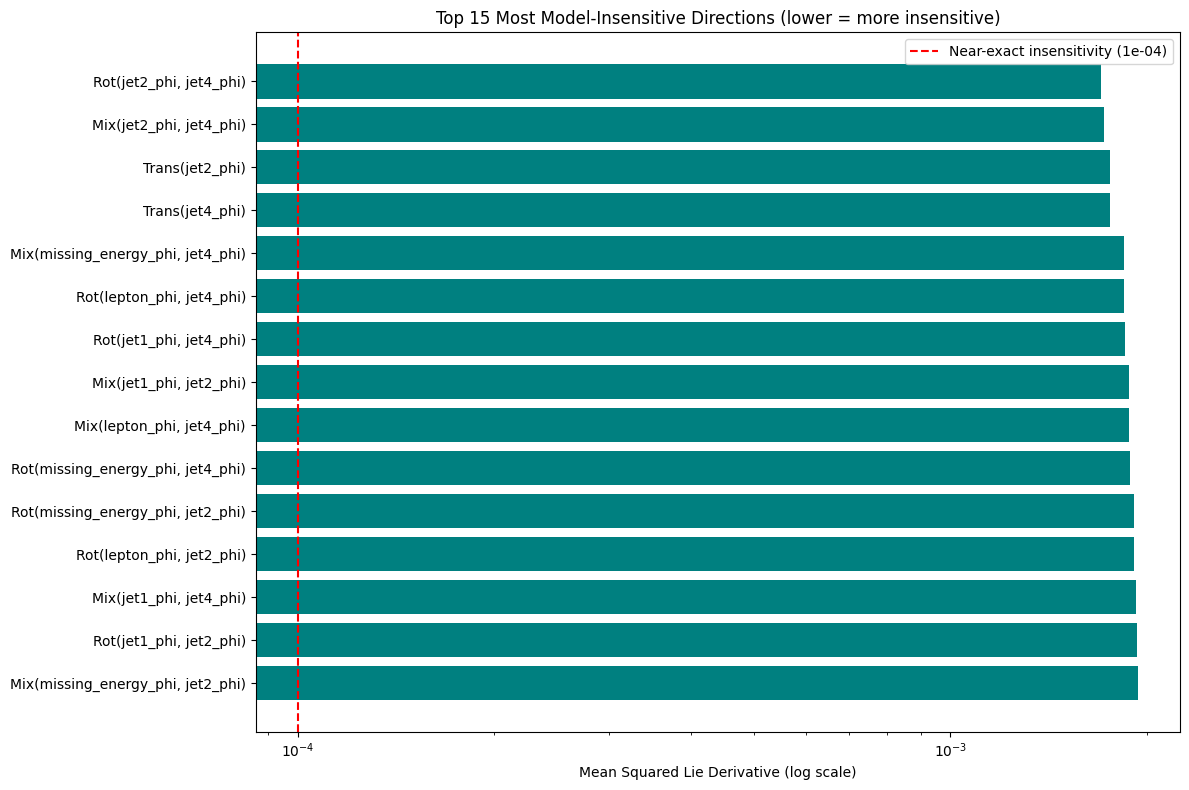

1. Physical U(1) (global phi shift):
   Score 3.35e-03 -> the model is only APPROXIMATELY insensitive (score above the near-exact threshold). Low sensitivity to phi is expected regardless of symmetry learning, because marginal phi is nearly uninformative for the label.

2. Per-feature phi translations (model insensitivity only — shifting a single
   phi changes the inter-object angles and is NOT a physical symmetry):
   Trans(jet2_phi): 1.75e-03
   Trans(jet4_phi): 1.76e-03
   Trans(jet1_phi): 2.03e-03
   Trans(lepton_phi): 2.06e-03
   Trans(missing_energy_phi): 2.09e-03
   Trans(jet3_phi): 2.41e-03

3. Most-insensitive jet-jet feature mixings (linear probes; note that jet
   permutations are discrete and NOT expressible as these infinitesimal generators):
   Rot(jet2_phi, jet4_phi): 1.70e-03
   Mix(jet2_phi, jet4_phi): 1.72e-03
   Rot(jet1_phi, jet4_phi): 1.85e-03
   Mix(jet1_phi, jet2_phi): 1.87e-03
   Mix(jet1_phi, jet4_phi): 1.92e-03


In [19]:
sorted_indices = np.argsort(lie_scores)
top_k = 15
top_names = [gen_names[i] for i in sorted_indices[:top_k]]
top_scores = lie_scores[sorted_indices[:top_k]]

EXACT_THRESHOLD = 1e-4  # heuristic cutoff for near-exact model insensitivity

plt.figure(figsize=(12, 8))
colors = ['#d62728' if 'PHYSICAL' in n or 'HEURISTIC' in n else 'teal' for n in top_names]
plt.barh(top_names[::-1], top_scores[::-1], color=colors[::-1])
plt.xscale('log')
plt.xlabel('Mean Squared Lie Derivative (log scale)')
plt.title(f'Top {top_k} Most Model-Insensitive Directions (lower = more insensitive)')
plt.axvline(x=EXACT_THRESHOLD, color='red', linestyle='--',
            label=f'Near-exact insensitivity ({EXACT_THRESHOLD:.0e})')
plt.legend()
plt.tight_layout()
plt.show()

# --- Interpretation (respecting the threshold) ---
u1_score = lie_scores[0]
print("1. Physical U(1) (global phi shift):")
print(f"   Score {u1_score:.2e} -> " +
      ("NEAR-EXACT insensitivity: consistent with the model having learned "
       "(approximate) azimuthal invariance." if u1_score < EXACT_THRESHOLD else
       "the model is only APPROXIMATELY insensitive (score above the near-exact "
       "threshold). Low sensitivity to phi is expected regardless of symmetry "
       "learning, because marginal phi is nearly uninformative for the label."))

# Per-feature phi translations: model insensitivity, NOT physical symmetry
phi_trans = [(n, lie_scores[gen_names.index(n)]) for n in gen_names
             if n.startswith('Trans') and 'phi' in n]
phi_trans.sort(key=lambda t: t[1])
print("\n2. Per-feature phi translations (model insensitivity only — shifting a single")
print("   phi changes the inter-object angles and is NOT a physical symmetry):")
for n, s in phi_trans:
    print(f"   {n}: {s:.2e}")

# Jet-jet mixings: require BOTH features to be jet features
def both_jets(name):
    if not (name.startswith('Rot') or name.startswith('Mix')):
        return False
    inner = name[name.index('(') + 1:name.rindex(')')]
    f1, f2 = [s.strip() for s in inner.split(',')]
    return f1.startswith('jet') and f2.startswith('jet')

jet_jet = [(gen_names[i], lie_scores[i]) for i in sorted_indices if both_jets(gen_names[i])][:5]
print("\n3. Most-insensitive jet-jet feature mixings (linear probes; note that jet")
print("   permutations are discrete and NOT expressible as these infinitesimal generators):")
for n, s in jet_jet:
    print(f"   {n}: {s:.2e}")

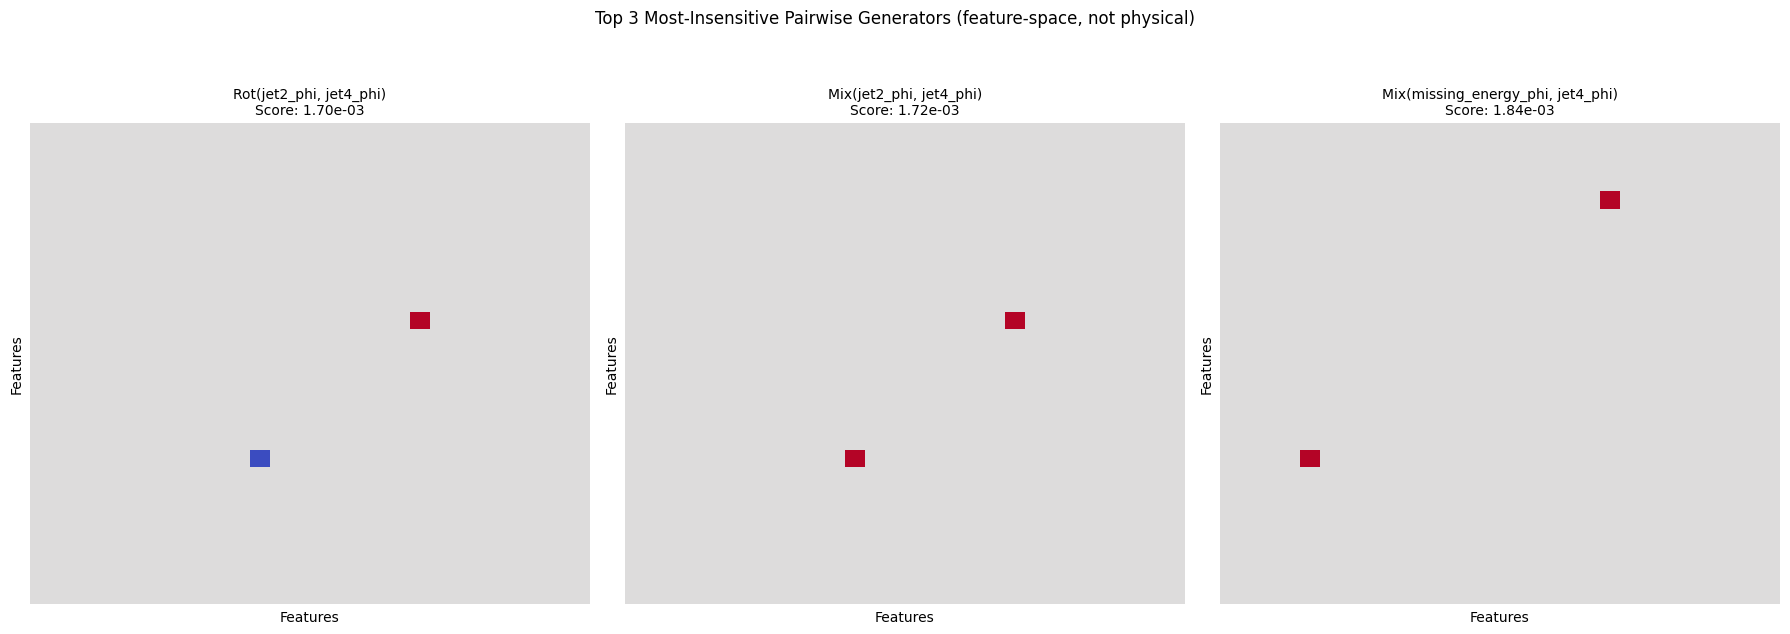

In [20]:
# Visualize the structure of the top pairwise (matrix) generators
matrix_idx = [i for i, g in enumerate(generators) if np.asarray(g).ndim == 2]
matrix_scores = lie_scores[matrix_idx]
top3_local = np.argsort(matrix_scores)[:3]
top3_global = [matrix_idx[i] for i in top3_local]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, gi in zip(axes, top3_global):
    sns.heatmap(generators[gi], cmap='coolwarm', center=0, ax=ax,
                xticklabels=False, yticklabels=False, cbar=False)
    ax.set_title(f"{gen_names[gi]}\nScore: {lie_scores[gi]:.2e}", fontsize=10)
    ax.set_xlabel("Features"); ax.set_ylabel("Features")
plt.suptitle('Top 3 Most-Insensitive Pairwise Generators (feature-space, not physical)', y=1.05)
plt.tight_layout()
plt.show()

# Point cloud topology

Exploratory comparison of persistence diagrams for three feature subsets. **Caveats:**
H0/H1 counts are not comparable across spaces of different ambient dimension (28D vs 22D
vs 7D) — the expected number of noise-driven H1 classes depends strongly on dimension and
sampling density, and 200 points is far too sparse to estimate the topology of any of
these spaces. Differences below describe the *samples*, not established topology of the
data manifold.

In [21]:
np.random.seed(42)
subsample_idx = np.random.choice(len(X_test), 200, replace=False)
X_sub = X_test[subsample_idx]

# For a fair-ish comparison all three variants are standardized ON THE SAME SUBSAMPLE.
X_raw_sub = StandardScaler().fit_transform(X_sub)

X_u1 = np.delete(X_sub, PHI_IDX, axis=1)                  # drop phi -> U(1)-invariant description
X_u1 = StandardScaler().fit_transform(X_u1)               # (note: this also drops Delta-phi info)

X_lorentz = X_sub[:, 21:28]                               # the 7 invariant masses
X_lorentz = StandardScaler().fit_transform(X_lorentz)

datasets = {
    "Raw (28D)": X_raw_sub,
    "Phi-dropped (22D)": X_u1,
    "Invariant masses (7D)": X_lorentz
}
for name, Xd in datasets.items():
    print(f"{name}: {Xd.shape}")

Raw (28D): (200, 28)
Phi-dropped (22D): (200, 22)
Invariant masses (7D): (200, 7)


In [22]:
diagrams_dict = {}
for name, Xd in datasets.items():
    start = time.time()
    dgms = ripser.ripser(Xd, maxdim=1)['dgms']  # H0 and H1 (H2 too slow for 200 pts)
    diagrams_dict[name] = dgms
    print(f"{name}: {time.time()-start:.2f}s | H0: {len(dgms[0])}, H1: {len(dgms[1])}")

Raw (28D): 0.05s | H0: 200, H1: 232
Phi-dropped (22D): 0.04s | H0: 200, H1: 161
Invariant masses (7D): 0.03s | H0: 200, H1: 91


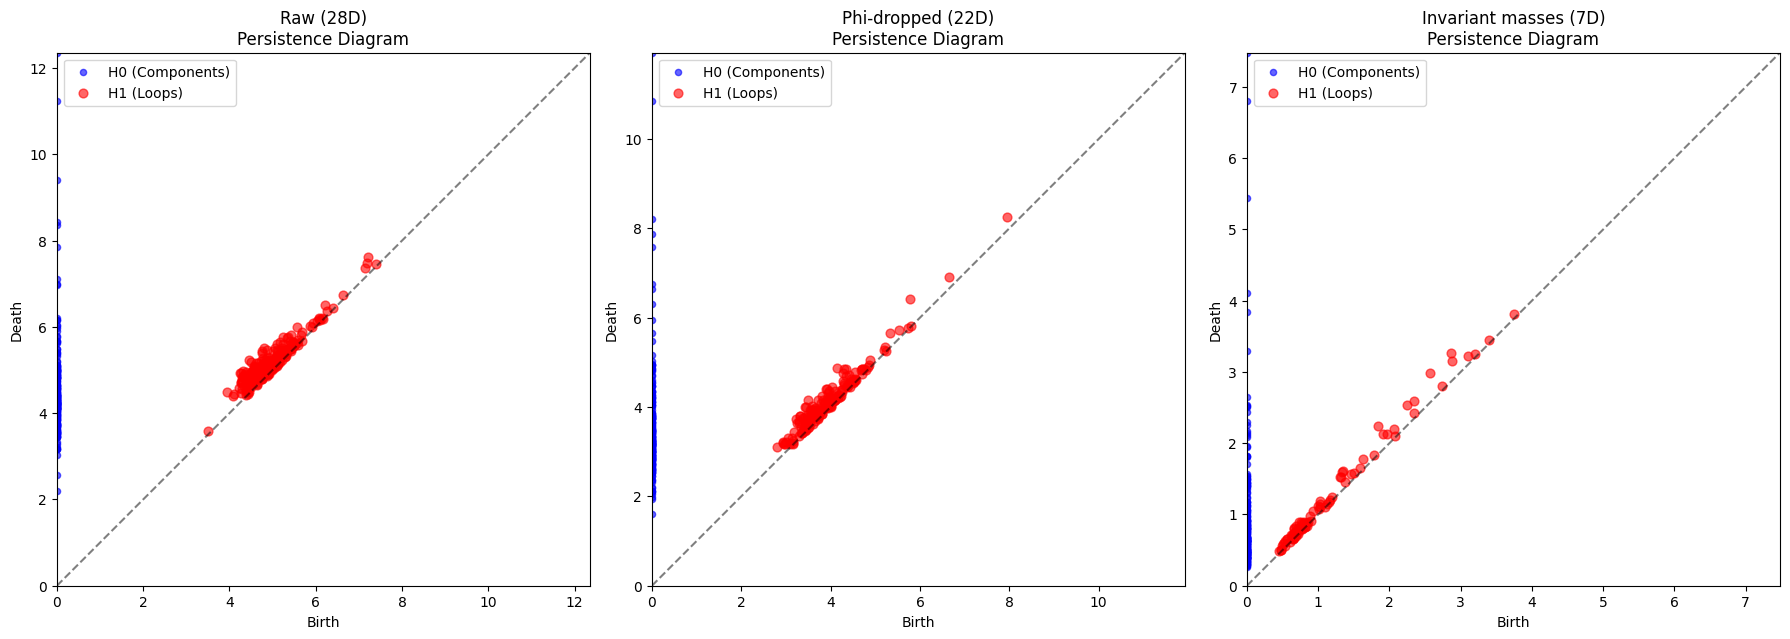

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, dgms) in zip(axes, diagrams_dict.items()):
    finite_deaths = np.concatenate([d[np.isfinite(d[:, 1]), 1] for d in dgms if len(d)])
    cap = (finite_deaths.max() if len(finite_deaths) else 1.0) * 1.1

    for dgm, c, lbl, s in [(dgms[0], 'blue', 'H0 (Components)', 20),
                           (dgms[1], 'red', 'H1 (Loops)', 40)]:
        if len(dgm):
            deaths = np.where(np.isfinite(dgm[:, 1]), dgm[:, 1], cap)
            ax.scatter(dgm[:, 0], deaths, c=c, label=lbl, alpha=0.6, s=s)
    ax.plot([0, cap], [0, cap], 'k--', alpha=0.5)
    ax.set_title(f'{name}\nPersistence Diagram', fontsize=12)
    ax.set_xlabel('Birth'); ax.set_ylabel('Death')
    ax.legend(); ax.set_aspect('equal')
    ax.set_xlim(0, cap); ax.set_ylim(0, cap)
plt.tight_layout()
plt.show()

Computing Rips persistence up to H2 on 100 points...
Time: 0.15s


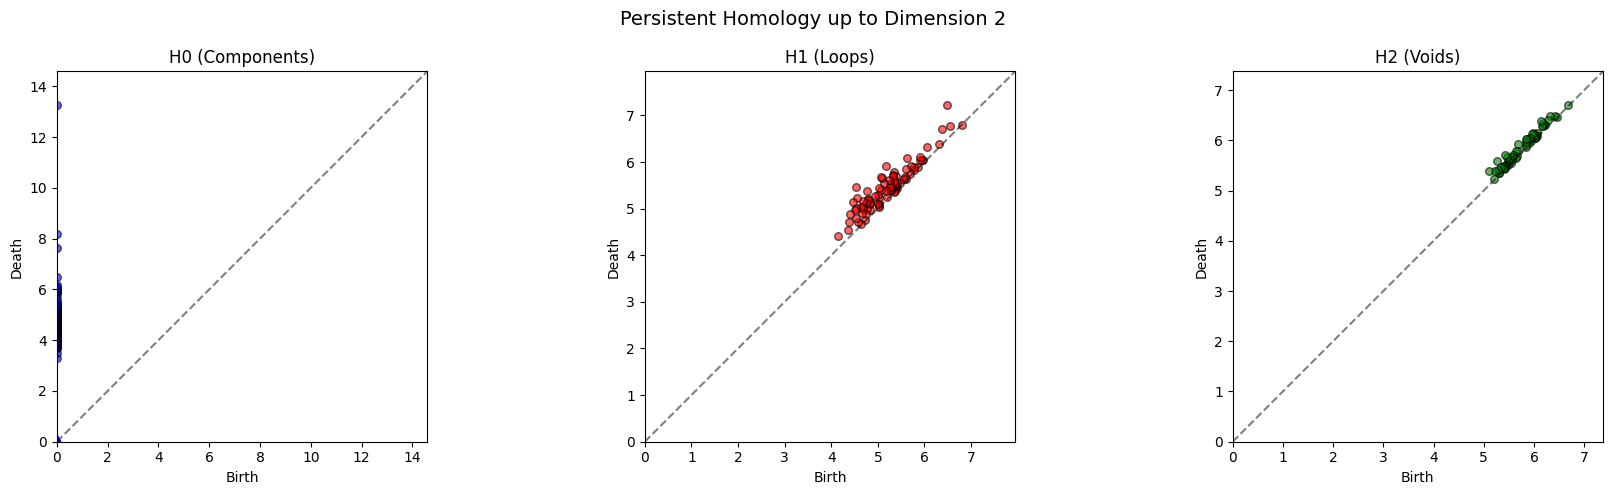

H0: 100 features, mean persistence of finite: 4.8875
H1: 87 features, mean persistence of finite: 0.2587
H2: 56 features, mean persistence of finite: 0.1002


In [24]:
# H2 computation is even more expensive. Use a tiny subset.
n_points = 100
np.random.seed(123)
subsample_idx = np.random.choice(len(X_test), n_points, replace=False)
X_sub = scaler.transform(X_test[subsample_idx])

print(f"Computing Rips persistence up to H2 on {n_points} points...")
start = time.time()
dgms = ripser.ripser(X_sub, maxdim=2)['dgms']   # This will compute H0, H1, H2
print(f"Time: {time.time()-start:.2f}s")

# Plot all three diagrams
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_dgm(ax, dgm, title, color):
    if len(dgm) == 0:
        ax.set_title(title + "\n(empty)")
        return
    finite = dgm[:, 1] != np.inf
    if finite.any():
        ax.scatter(dgm[finite, 0], dgm[finite, 1], c=color, alpha=0.6, s=30, edgecolors='black')
    inf_mask = dgm[:, 1] == np.inf
    if inf_mask.any():
        max_birth = np.max(dgm[:, 0])
        ax.scatter(dgm[inf_mask, 0], [max_birth*1.1]*inf_mask.sum(), c=color, marker='^', s=100)
    # Diagonal
    all_finite = dgm[finite]
    if len(all_finite) > 0:
        max_val = max(np.max(all_finite[:, 0]), np.max(all_finite[:, 1])) * 1.1
    else:
        max_val = np.max(dgm[:, 0]) * 1.1
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5)
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel('Birth')
    ax.set_ylabel('Death')

plot_dgm(axes[0], dgms[0], 'H0 (Components)', 'blue')
plot_dgm(axes[1], dgms[1], 'H1 (Loops)', 'red')
plot_dgm(axes[2], dgms[2], 'H2 (Voids)', 'green')

plt.suptitle('Persistent Homology up to Dimension 2', fontsize=14)
plt.tight_layout()
plt.show()

# Print summary
for dim, dgm in enumerate(dgms):
    count = len(dgm)
    if count == 0:
        print(f"H{dim}: no features")
    else:
        finite_deaths = dgm[dgm[:,1]!=np.inf, 1]
        if len(finite_deaths)>0:
            mean_persist = np.mean(finite_deaths - dgm[dgm[:,1]!=np.inf, 0])
        else:
            mean_persist = 0
        print(f"H{dim}: {count} features, mean persistence of finite: {mean_persist:.4f}")

Computing diagrams for persistent entropy...

Persistent Entropy 
Signal - H0: 5.6838, H1: 5.4728
Background - H0: 5.6830, H1: 5.5084


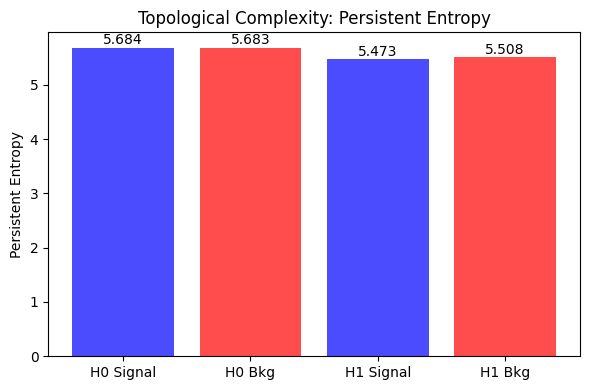

In [25]:
# Balanced subsamples
n_per_class = 300
np.random.seed(42)
signal_idx = np.where(y_test == 1)[0]
bkg_idx = np.where(y_test == 0)[0]

signal_sub = np.random.choice(signal_idx, min(n_per_class, len(signal_idx)), replace=False)
bkg_sub = np.random.choice(bkg_idx, min(n_per_class, len(bkg_idx)), replace=False)

X_signal = scaler.transform(X_test[signal_sub])
X_bkg = scaler.transform(X_test[bkg_sub])

print("Computing diagrams for persistent entropy...")
dgms_signal = ripser.ripser(X_signal, maxdim=1)['dgms']
dgms_bkg = ripser.ripser(X_bkg, maxdim=1)['dgms']




def safe_entropy(dgm, min_persistence=0.1):
    if len(dgm) == 0:
        return 0.0
    finite = dgm[dgm[:, 1] != np.inf]
    lifespans = finite[:, 1] - finite[:, 0]
    mask = lifespans > min_persistence
    if mask.sum() == 0:
        return 0.0
    return float(persistent_entropy(finite[mask]))
entropy_signal_h0 = safe_entropy(dgms_signal[0])
entropy_signal_h1 = safe_entropy(dgms_signal[1])
entropy_bkg_h0 = safe_entropy(dgms_bkg[0])
entropy_bkg_h1 = safe_entropy(dgms_bkg[1])

print("\nPersistent Entropy ")
print(f"Signal - H0: {entropy_signal_h0:.4f}, H1: {entropy_signal_h1:.4f}")
print(f"Background - H0: {entropy_bkg_h0:.4f}, H1: {entropy_bkg_h1:.4f}")

# Bar plot
categories = ['H0 Signal', 'H0 Bkg', 'H1 Signal', 'H1 Bkg']
entropies = [entropy_signal_h0, entropy_bkg_h0, entropy_signal_h1, entropy_bkg_h1]
plt.figure(figsize=(6,4))
bars = plt.bar(categories, entropies, color=['blue','red','blue','red'], alpha=0.7)
plt.ylabel('Persistent Entropy')
plt.title('Topological Complexity: Persistent Entropy')
for bar, val in zip(bars, entropies):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

Signal points: 500, Background points: 500
Computing persistence for signal class...
  Time: 0.35s
Computing persistence for background class...
  Time: 0.34s


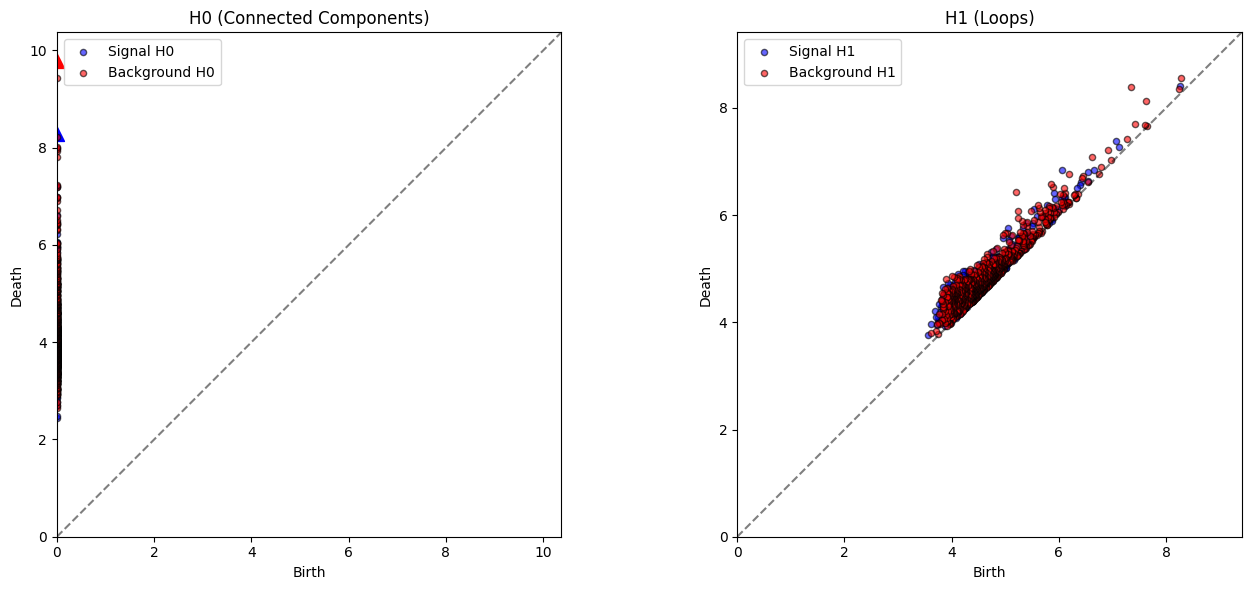

Bottleneck distance (H0): 1.4275
Bottleneck distance (H1): 0.5206
(Larger distance suggests more topological difference between classes)


In [26]:
# Use a larger sample, but balance classes for fair comparison
n_per_class = 500  # Ripser ~ O(N^3), 1000 total points is still reasonable

# Separate signal and background indices
signal_idx = np.where(y_test == 1)[0]
bkg_idx = np.where(y_test == 0)[0]

# Sample from each class
np.random.seed(42)
signal_sub = np.random.choice(signal_idx, min(n_per_class, len(signal_idx)), replace=False)
bkg_sub = np.random.choice(bkg_idx, min(n_per_class, len(bkg_idx)), replace=False)

X_signal_raw = X_test[signal_sub]
X_bkg_raw = X_test[bkg_sub]

# Use the already-fitted scaler (from training data) to ensure same scale
X_signal = scaler.transform(X_signal_raw)
X_bkg = scaler.transform(X_bkg_raw)

print(f"Signal points: {X_signal.shape[0]}, Background points: {X_bkg.shape[0]}")

# Compute persistence diagrams
print("Computing persistence for signal class...")
start = time.time()
dgms_signal = ripser.ripser(X_signal, maxdim=1)['dgms']
print(f"  Time: {time.time()-start:.2f}s")

print("Computing persistence for background class...")
start = time.time()
dgms_bkg = ripser.ripser(X_bkg, maxdim=1)['dgms']
print(f"  Time: {time.time()-start:.2f}s")

# Plot both diagrams on the same axes
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Helper function to plot diagram ignoring infinite death
def plot_diagram(ax, dgm, color, label, marker_size=20):
    if len(dgm) == 0:
        return
    finite = dgm[:, 1] != np.inf
    ax.scatter(dgm[finite, 0], dgm[finite, 1], c=color, label=label, alpha=0.6, s=marker_size, edgecolors='black')
    # If infinite deaths exist, show them at top with arrow (optional)
    inf_mask = dgm[:, 1] == np.inf
    if np.any(inf_mask):
        ax.scatter(dgm[inf_mask, 0], [ax.get_ylim()[1]]*inf_mask.sum(), c=color, marker='^', s=100, label='_nolegend_')

# Plot H0
ax0 = axes[0]
plot_diagram(ax0, dgms_signal[0], 'blue', 'Signal H0')
plot_diagram(ax0, dgms_bkg[0], 'red', 'Background H0')
ax0.set_title('H0 (Connected Components)')
ax0.set_xlabel('Birth')
ax0.set_ylabel('Death')
ax0.legend()
ax0.set_aspect('equal')
# Determine limits
max_h0 = max(np.max(dgms_signal[0][dgms_signal[0][:,1]!=np.inf, 1]) if len(dgms_signal[0]) else 0,
             np.max(dgms_bkg[0][dgms_bkg[0][:,1]!=np.inf, 1]) if len(dgms_bkg[0]) else 0)
if max_h0 == 0: max_h0 = 1
lim = max_h0 * 1.1
ax0.plot([0, lim], [0, lim], 'k--', alpha=0.5)
ax0.set_xlim(0, lim)
ax0.set_ylim(0, lim)

# Plot H1
ax1 = axes[1]
plot_diagram(ax1, dgms_signal[1], 'blue', 'Signal H1')
plot_diagram(ax1, dgms_bkg[1], 'red', 'Background H1')
ax1.set_title('H1 (Loops)')
ax1.set_xlabel('Birth')
ax1.set_ylabel('Death')
ax1.legend()
ax1.set_aspect('equal')
max_h1 = max(np.max(dgms_signal[1][:,1]) if len(dgms_signal[1]) else 0,
             np.max(dgms_bkg[1][:,1]) if len(dgms_bkg[1]) else 0)
if max_h1 == 0: max_h1 = 1
lim1 = max_h1 * 1.1
ax1.plot([0, lim1], [0, lim1], 'k--', alpha=0.5)
ax1.set_xlim(0, lim1)
ax1.set_ylim(0, lim1)

plt.tight_layout()
plt.show()

# Bottleneck distances
if len(dgms_signal[0]) > 0 and len(dgms_bkg[0]) > 0:
    d0 = bottleneck(dgms_signal[0], dgms_bkg[0])
else:
    d0 = np.nan
if len(dgms_signal[1]) > 0 and len(dgms_bkg[1]) > 0:
    d1 = bottleneck(dgms_signal[1], dgms_bkg[1])
else:
    d1 = np.nan

print(f"Bottleneck distance (H0): {d0:.4f}")
print(f"Bottleneck distance (H1): {d1:.4f}")
print("(Larger distance suggests more topological difference between classes)")

Computing lower‑star persistence on graph...
Time: 0.00s


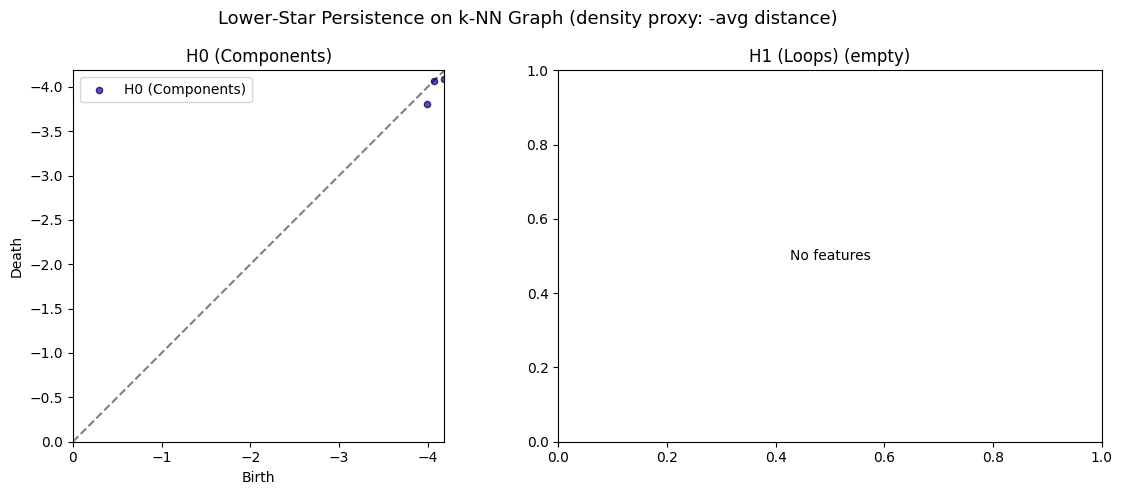

H0 features: 110 (finite: 109)
H1 features: 0 (finite: 0)


In [27]:
# Parameters
n_points = 800                     # number of points to sample
k = 10                             # number of nearest neighbors for the graph
max_death_plot = None              # will be set automatically

# 1. Subsample the test data
np.random.seed(42)
sub_idx = np.random.choice(len(X_test), n_points, replace=False)
X_sub = scaler.transform(X_test[sub_idx])
y_sub = y_test[sub_idx]

# 2. Compute a density proxy: negative of average distance to k‑th neighbor
#    (larger average distance → lower density → more negative value)
tree = KDTree(X_sub)
distances, _ = tree.query(X_sub, k=k+1)  # first neighbor is the point itself
avg_dist = distances[:, 1:].mean(axis=1) # average of k nearest neighbors (excluding self)
# Density proxy: inverse (or negative) of average distance
# For lower‑star filtration we want higher density to appear earlier;
# we use function f(x) = -log(avg_dist) or just -avg_dist.
# Using -avg_dist makes low‑density points have larger (less negative) values → appear later.
f_values = -avg_dist

# 3. Build k‑NN graph as a Gudhi Simplex Tree (only 0‑ and 1‑simplices)
st = gd.SimplexTree()

# Insert vertices with filtration values
for i, val in enumerate(f_values):
    st.insert([i], val)

# Insert edges: for each point, connect to its k nearest neighbors (undirected, avoid duplicates)
# Using KDTree indices
_, indices = tree.query(X_sub, k=k+1)  # again get indices
for i in range(n_points):
    for j in indices[i, 1:]:            # skip self
        if i < j:                       # avoid duplicate (i,j) and (j,i)
            # Lower‑star filtration value: max of vertex values
            val = max(f_values[i], f_values[j])
            st.insert([i, j], val)

# 4. Ensure the filtration is a valid filtration (sorted) and compute persistence
st.initialize_filtration()
print("Computing lower‑star persistence on graph...")
start = time.time()
diag = st.persistence()
print(f"Time: {time.time()-start:.2f}s")

# Convert to array format per dimension
dgm_h0 = []
dgm_h1 = []
for dim, (birth, death) in diag:
    if death == np.inf:
        death = np.inf
    if dim == 0:
        dgm_h0.append([birth, death])
    elif dim == 1:
        dgm_h1.append([birth, death])
dgm_h0 = np.array(dgm_h0) if dgm_h0 else np.empty((0,2))
dgm_h1 = np.array(dgm_h1) if dgm_h1 else np.empty((0,2))

# 5. Plot persistence diagram
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def plot_dgm(ax, dgm, color, label, marker='o', size=20):
    if len(dgm) == 0:
        ax.text(0.5, 0.5, 'No features', ha='center', va='center')
        ax.set_title(f'{label} (empty)')
        return
    finite = dgm[dgm[:, 1] != np.inf]
    inf_mask = dgm[:, 1] == np.inf
    if len(finite) > 0:
        ax.scatter(finite[:,0], finite[:,1], c=color, label=label, alpha=0.7, s=size, edgecolors='black')
    if inf_mask.any():
        # Plot essential features at top of axis
        max_birth = np.max(dgm[:, 0])
        ax.scatter(dgm[inf_mask, 0], [max_birth*1.1]*inf_mask.sum(), c=color, marker='^', s=100, label='_nolegend_')
    # Diagonal
    if len(finite) > 0:
        max_val = max(np.max(finite[:,0]), np.max(finite[:,1])) * 1.1
    else:
        max_val = np.max(dgm[:, 0]) * 1.1
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5)
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.set_aspect('equal')
    ax.set_title(label)
    ax.set_xlabel('Birth')
    ax.set_ylabel('Death')
    ax.legend()

plot_dgm(axes[0], dgm_h0, 'blue', 'H0 (Components)')
plot_dgm(axes[1], dgm_h1, 'red', 'H1 (Loops)', marker='s', size=30)

plt.suptitle('Lower‑Star Persistence on k‑NN Graph (density proxy: -avg distance)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"H0 features: {len(dgm_h0)} (finite: {np.sum(dgm_h0[:,1]!=np.inf) if len(dgm_h0)>0 else 0})")
print(f"H1 features: {len(dgm_h1)} (finite: {np.sum(dgm_h1[:,1]!=np.inf) if len(dgm_h1)>0 else 0})")

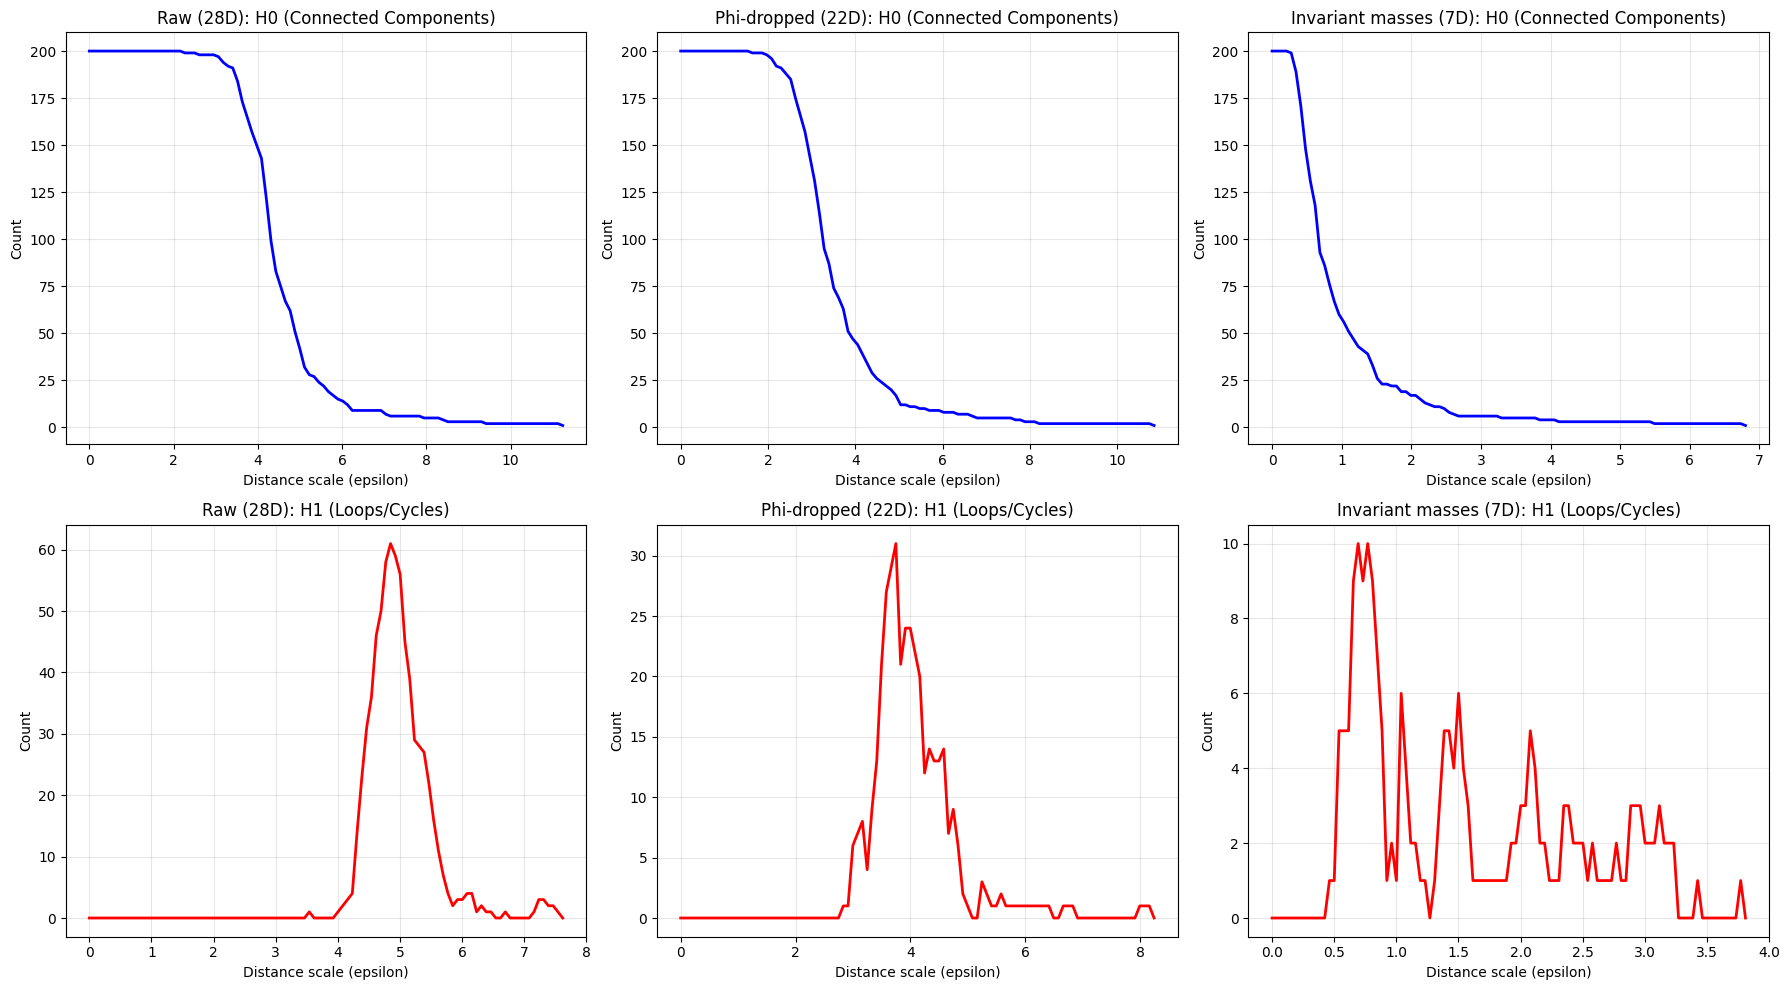

Raw (28D): H1 count 232, mean lifespan 0.2325, max lifespan 0.7638
Phi-dropped (22D): H1 count 161, mean lifespan 0.1951, max lifespan 0.7232
Invariant masses (7D): H1 count 91, mean lifespan 0.0906, max lifespan 0.4174

(Reminder: counts are not comparable across ambient dimensions — see caveat above.)


In [28]:
def compute_betti_curve(dgm, num_bins=100):
    """Number of alive features at each filtration value."""
    if len(dgm) == 0:
        return np.zeros(num_bins), np.zeros(num_bins)
    births, deaths = dgm[:, 0], dgm[:, 1]
    finite_deaths = deaths[np.isfinite(deaths)]
    if len(finite_deaths):
        max_val = np.max(finite_deaths)
    else:
        max_val = max(np.max(births) * 2, 1.0)  # guard: all-infinite diagram (e.g. pure H0 at birth 0)
    epsilons = np.linspace(0, max_val, num_bins)
    betti = np.array([np.sum((births <= e) & (deaths > e)) for e in epsilons])
    return epsilons, betti

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for col, (name, dgms) in enumerate(diagrams_dict.items()):
    eps0, b0 = compute_betti_curve(dgms[0])
    axes[0, col].plot(eps0, b0, color='blue', linewidth=2)
    axes[0, col].set_title(f'{name}: H0 (Connected Components)', fontsize=12)
    axes[0, col].set_xlabel('Distance scale (epsilon)'); axes[0, col].set_ylabel('Count')
    axes[0, col].grid(True, alpha=0.3)

    if len(dgms[1]):
        eps1, b1 = compute_betti_curve(dgms[1])
        axes[1, col].plot(eps1, b1, color='red', linewidth=2)
        axes[1, col].set_title(f'{name}: H1 (Loops/Cycles)', fontsize=12)
        axes[1, col].set_xlabel('Distance scale (epsilon)'); axes[1, col].set_ylabel('Count')
    else:
        axes[1, col].text(0.5, 0.5, 'No H1 features', ha='center', va='center', fontsize=12)
    axes[1, col].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for name, dgms in diagrams_dict.items():
    h1 = dgms[1]
    if len(h1):
        lifespans = h1[:, 1] - h1[:, 0]
        lifespans = lifespans[np.isfinite(lifespans)]
        print(f"{name}: H1 count {len(h1)}, mean lifespan {np.mean(lifespans):.4f}, "
              f"max lifespan {np.max(lifespans):.4f}")
    else:
        print(f"{name}: no H1 features")
print("\n(Reminder: counts are not comparable across ambient dimensions — see caveat above.)")

# Training an equivariant model (EGNN)

Symmetry respect box — what this model does and doesn't respect:

| Transformation | Physical symmetry? | EGNN respects it? |
|---|---|---|
| Rotation about beam (z) axis | **Yes** (SO(2)) | Yes — architecturally, via pairwise distances |
| Arbitrary 3D rotation of coords | **No** (beam axis is special; also pT node features would not co-transform) | Yes (imposed, unphysical) |
| Translation of all momenta | **No** (momentum space has no translation symmetry) | Yes (imposed, unphysical) |
| Jet permutation | Yes (labeling is order-independent) | Yes — mean pooling |

So the EGNN *imposes a strictly larger symmetry group than the physics has*. That acts as
an inductive-bias regularizer, not as "physics-correct equivariance". A physically exact
treatment would use SO(2)×(z-reflection) equivariance about the beam axis only.

Comparison caveat: the EGNN below consumes a *different* input representation than the
baselines (it drops lepton η/φ and MET φ entirely, and sees jets as a graph plus 9 global
scalars), and results come from a single seed — differences of a few 1e-3 in AUC between
it and the baselines are not attributable to equivariance alone.

In [29]:
from egnn_pytorch import EGNN

# --- Data prep for the EGNN, reusing the SAME split indices as the baselines ---
jet_cols_flat = np.array(JET_BLOCKS).flatten()
all_jets = X[:, jet_cols_flat].reshape(len(X), 4, 4)   # (N, 4 jets, [pt, eta, phi, btag])

jet_pts, jet_etas, jet_phis, jet_btags = (all_jets[:, :, k] for k in range(4))

# 3D pseudo-momenta with the corrected phi conversion (full azimuthal coverage)
jet_coords = kinematic_to_cartesian(jet_pts, jet_etas, jet_phis)   # (N, 4, 3)

# Node features: pT and b-tag. b-tag is a genuine scalar. pT is invariant under
# z-rotations (the physical symmetry) but NOT under arbitrary 3D rotations — one more
# reason the model's full-E(3) invariance is an approximation, not physics.
node_features = np.stack([jet_pts, jet_btags], axis=-1)            # (N, 4, 2)

# Global scalars: lepton pT, MET magnitude, 7 invariant masses (all z-rotation invariant).
# NOTE: lepton eta/phi and MET phi are intentionally dropped; the EGNN sees less
# information than the flat baselines.
global_features = np.hstack([X[:, [0]], X[:, [3]], X[:, 21:28]])   # (N, 9)

X_node_train, X_node_test = node_features[idx_train], node_features[idx_test]
X_coord_train, X_coord_test = jet_coords[idx_train], jet_coords[idx_test]
X_glob_train, X_glob_test = global_features[idx_train], global_features[idx_test]
# y_train / y_test are unchanged from the baseline cells (same idx_train / idx_test)

# Node features: per-feature standardization (scalars; no equivariance constraint)
scaler_node = StandardScaler().fit(X_node_train.reshape(-1, 2))
X_node_train = scaler_node.transform(X_node_train.reshape(-1, 2)).reshape(-1, 4, 2)
X_node_test  = scaler_node.transform(X_node_test.reshape(-1, 2)).reshape(-1, 4, 2)

# Coordinates: ONE global scale factor, so rotational equivariance is preserved
# (per-component standardization would break it)
coord_scale = np.sqrt(np.mean(np.linalg.norm(X_coord_train.reshape(-1, 3), axis=-1) ** 2))
X_coord_train = X_coord_train / coord_scale
X_coord_test  = X_coord_test / coord_scale

scaler_glob = StandardScaler().fit(X_glob_train)
X_glob_train = scaler_glob.transform(X_glob_train)
X_glob_test  = scaler_glob.transform(X_glob_test)

egnn_train_dataset = TensorDataset(
    torch.tensor(X_node_train, dtype=torch.float32),
    torch.tensor(X_coord_train, dtype=torch.float32),
    torch.tensor(X_glob_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
)
egnn_test_dataset = TensorDataset(
    torch.tensor(X_node_test, dtype=torch.float32),
    torch.tensor(X_coord_test, dtype=torch.float32),
    torch.tensor(X_glob_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
)
egnn_train_loader = DataLoader(egnn_train_dataset, batch_size=1024, shuffle=True)
egnn_test_loader  = DataLoader(egnn_test_dataset, batch_size=1024, shuffle=False)

print(f"Graph data prepared. Nodes: 4 jets. coord_scale = {coord_scale:.4f}")

Graph data prepared. Nodes: 4 jets. coord_scale = 2.0304


In [30]:
class HiggsEGNN(nn.Module):
    """EGNN-based classifier. See the 'symmetry respect box' above: the network is
    invariant under E(3) transforms of the coordinates, which is a larger
    group than the physical SO(2)-about-beam-axis symmetry."""
    def __init__(self, node_dim=2, hidden_dim=64, message_dim=32, num_layers=3, glob_dim=9):
        super().__init__()
        self.node_emb = nn.Linear(node_dim, hidden_dim)
        self.egnn_layers = nn.ModuleList([
            EGNN(dim=hidden_dim, m_dim=message_dim) for _ in range(num_layers)
        ])
        self.readout_mlp = nn.Sequential(
            nn.Linear(hidden_dim + glob_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, h, x, glob_feats):
        h = self.node_emb(h)                       # (B, 4, hidden)
        for layer in self.egnn_layers:             # fully-connected graph by default
            h, x = layer(h, x)
        h_pooled = h.mean(dim=1)                   # permutation-invariant pooling
        return self.readout_mlp(torch.cat([h_pooled, glob_feats], dim=1))

torch.manual_seed(42)
model_egnn = HiggsEGNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model_egnn.parameters(), lr=0.001, weight_decay=1e-4)

print(f"Training EGNN on {device}...")
epochs = 15
start_time = time.time()
for epoch in range(epochs):
    model_egnn.train()
    epoch_loss = 0
    for batch_h, batch_x, batch_glob, batch_y in egnn_train_loader:
        batch_h, batch_x = batch_h.to(device), batch_x.to(device)
        batch_glob, batch_y = batch_glob.to(device), batch_y.to(device)
        optimizer.zero_grad()
        loss = criterion(model_egnn(batch_h, batch_x, batch_glob), batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 3 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(egnn_train_loader):.4f}")
print(f"Total training time: {time.time() - start_time:.2f}s")

model_egnn.eval()
probs = []
with torch.no_grad():
    for batch_h, batch_x, batch_glob, _ in egnn_test_loader:
        logits = model_egnn(batch_h.to(device), batch_x.to(device), batch_glob.to(device))
        probs.append(torch.sigmoid(logits).cpu().numpy())
egnn_probs = np.concatenate(probs).ravel()
print(f"\nEGNN Test ROC-AUC: {roc_auc_score(y_test, egnn_probs):.4f}")

Training EGNN on cuda...
Epoch [3/15], Loss: 0.5590
Epoch [6/15], Loss: 0.5411
Epoch [9/15], Loss: 0.5302
Epoch [12/15], Loss: 0.5234
Epoch [15/15], Loss: 0.5190
Total training time: 57.03s

EGNN Test ROC-AUC: 0.8196


In [31]:
# --- EGNN symmetry checks ---
batch_h, batch_x, batch_glob, batch_y = next(iter(egnn_test_loader))
batch_h, batch_x, batch_glob = batch_h.to(device), batch_x.to(device), batch_glob.to(device)

model_egnn.eval()
with torch.no_grad():
    base_logits = model_egnn(batch_h, batch_x, batch_glob).cpu().numpy().ravel()

# Test 1: rotation about the z (beam) axis — the PHYSICAL symmetry.
# Node features (pT, b-tag) and global scalars are all invariant under this rotation,
# so the whole input representation transforms consistently.
theta = np.pi / 2
rot_matrix = torch.tensor([
    [np.cos(theta), -np.sin(theta), 0],
    [np.sin(theta),  np.cos(theta), 0],
    [0,              0,             1]
], dtype=torch.float32, device=device)
with torch.no_grad():
    rot_logits = model_egnn(batch_h, batch_x @ rot_matrix.T, batch_glob).cpu().numpy().ravel()
diff_rot = np.abs(base_logits - rot_logits)

print("=" * 60)
print("TEST 1: Rotation about the beam (z) axis by 90 deg")
print(f"  Mean |dlogit|: {np.mean(diff_rot):.2e}   Max |dlogit|: {np.max(diff_rot):.2e}")
print("  " + ("OK: invariant up to float32 error (architectural guarantee; the same "
              "guarantee holds for ANY 3D rotation of the coords, which is MORE "
              "symmetry than the physics has)." if np.max(diff_rot) < 1e-4
              else "WARNING: invariance broken beyond float tolerance."))

# Test 2: jet permutation — mean pooling should make this exact up to float error.
perm = torch.tensor([3, 2, 1, 0], device=device)
with torch.no_grad():
    perm_logits = model_egnn(batch_h[:, perm, :], batch_x[:, perm, :], batch_glob).cpu().numpy().ravel()
diff_perm = np.abs(base_logits - perm_logits)
print("-" * 60)
print("TEST 2: Jet permutation (reversed order)")
print(f"  Mean |dlogit|: {np.mean(diff_perm):.2e}   Max |dlogit|: {np.max(diff_perm):.2e}")
print("  " + ("OK: permutation invariant up to float32 error." if np.max(diff_perm) < 1e-4
              else "WARNING: permutation invariance broken."))

# Test 3: eta-shift robustness probe (sigma-units; NOT a Lorentz boost — see earlier
# docstring; additionally eta here lives inside sinh(), so the coords must be rebuilt).
coords_unscaled = batch_x * coord_scale
px, py, pz = coords_unscaled[..., 0], coords_unscaled[..., 1], coords_unscaled[..., 2]
pt = torch.sqrt(px**2 + py**2 + 1e-12)
phi = torch.atan2(py, px)
eta = torch.arcsinh(pz / pt)            # recovers eta in sigma-units (as constructed)
pz_new = pt * torch.sinh(eta + DELTA_ETA_SIGMA)
coords_shifted = torch.stack([pt * torch.cos(phi), pt * torch.sin(phi), pz_new], dim=-1)
with torch.no_grad():
    shift_logits = model_egnn(batch_h, coords_shifted / coord_scale, batch_glob).cpu().numpy().ravel()
diff_shift = np.abs(base_logits - shift_logits)
print("-" * 60)
print(f"TEST 3: Eta-shift probe (delta_eta = {DELTA_ETA_SIGMA} sigma-units)")
print(f"  Mean |dlogit|: {np.mean(diff_shift):.6f}   Max |dlogit|: {np.max(diff_shift):.6f}")
print("  (Changes expected: this is not a symmetry of the model or of the data.)")
print("=" * 60)

TEST 1: Rotation about the beam (z) axis by 90 deg
  Mean |dlogit|: 2.30e-07   Max |dlogit|: 1.91e-06
  OK: invariant up to float32 error (architectural guarantee; the same guarantee holds for ANY 3D rotation of the coords, which is MORE symmetry than the physics has).
------------------------------------------------------------
TEST 2: Jet permutation (reversed order)
  Mean |dlogit|: 3.10e-07   Max |dlogit|: 1.67e-06
  OK: permutation invariant up to float32 error.
------------------------------------------------------------
TEST 3: Eta-shift probe (delta_eta = 0.5 sigma-units)
  Mean |dlogit|: 0.151664   Max |dlogit|: 1.827081
  (Changes expected: this is not a symmetry of the model or of the data.)


MODEL PERFORMANCE COMPARISON
                     ROC-AUC  PR-AUC (AP)  Accuracy  Precision  Recall      F1 Jet-permutation invariant    z-rotation invariant
LightGBM (Baseline)   0.8078       0.8227    0.7274     0.7400  0.7464  0.7432                        No                      No
Standard MLP          0.7996       0.8128    0.7231     0.7336  0.7474  0.7404                        No                      No
EGNN (Equivariant)    0.8196       0.8327    0.7376     0.7655  0.7259  0.7451    Yes (verified, Test 2)  Yes (verified, Test 1)
Notes:
 - single seed, single split: AUC differences of O(0.005) are not reliable;
 - the EGNN sees a different input representation (no lepton eta/phi, no MET phi),
   so differences are not attributable to equivariance alone;
 - the EGNN's invariance group (E(3) on coords) is larger than the physical
   symmetry (rotations about the beam axis) — see the honesty box above.


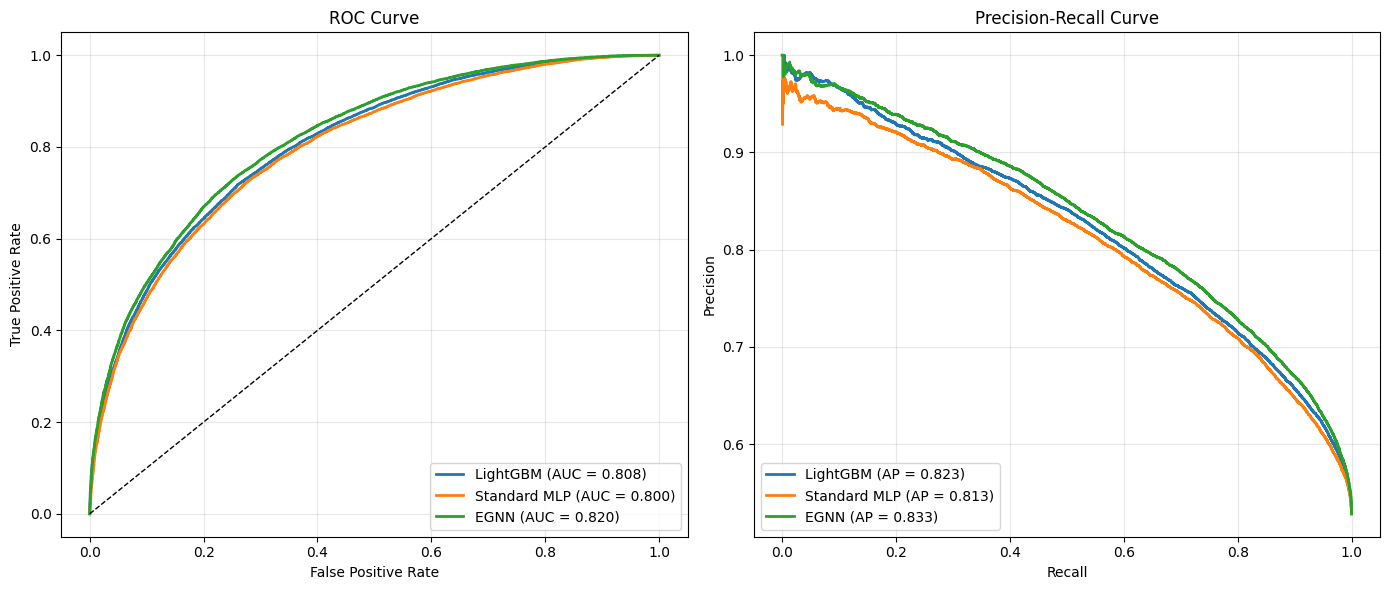

In [32]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             average_precision_score, roc_curve, precision_recall_curve)

# All three models are evaluated on the SAME test rows (idx_test), by construction.
mlp_probs = y_prob_mlp
lgb_probs = y_prob_lgb

results = {}
for name, probs in [('LightGBM (Baseline)', lgb_probs),
                    ('Standard MLP', mlp_probs),
                    ('EGNN (Equivariant)', egnn_probs)]:
    preds = (probs > 0.5).astype(int)
    results[name] = {
        'ROC-AUC': roc_auc_score(y_test, probs),
        'PR-AUC (AP)': average_precision_score(y_test, probs),
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
    }

df_metrics = pd.DataFrame(results).T
# Only properties that were actually verified above are claimed:
df_metrics['Jet-permutation invariant'] = ['No', 'No', 'Yes (verified, Test 2)']
df_metrics['z-rotation invariant'] = ['No', 'No', 'Yes (verified, Test 1)']

print("=" * 100)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 100)
print(df_metrics.round(4).to_string())
print("=" * 100)
print("Notes:")
print(" - single seed, single split: AUC differences of O(0.005) are not reliable;")
print(" - the EGNN sees a different input representation (no lepton eta/phi, no MET phi),")
print("   so differences are not attributable to equivariance alone;")
print(" - the EGNN's invariance group (E(3) on coords) is larger than the physical")
print("   symmetry (rotations about the beam axis) — see the honesty box above.")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for probs, name, color in zip([lgb_probs, mlp_probs, egnn_probs],
                              ['LightGBM', 'Standard MLP', 'EGNN'],
                              ['#1f77b4', '#ff7f0e', '#2ca02c']):
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{name} (AUC = {roc_auc_score(y_test, probs):.3f})')
    prec, rec, _ = precision_recall_curve(y_test, probs)
    axes[1].plot(rec, prec, color=color, linewidth=2,
                 label=f'{name} (AP = {average_precision_score(y_test, probs):.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend(loc='lower right'); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(loc='lower left'); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary of conclusions

- All three models reach ROC-AUC ≈ 0.80–0.85 on the 200k subset; differences between
  them are within single-seed noise and representation differences.
- Under a **correct** azimuthal rotation (units fixed), the MLP's predictions barely
  move — consistent with φ features being nearly uninformative, and NOT proof that the
  model "learned" the symmetry.
- EGNN is exactly permutation invariant by construction.
- The Lie-derivative probe includes the physical U(1) generator; its score quantifies
  how azimuth-insensitive the trained MLP actually is. Per-feature φ shifts and pairwise
  feature "rotations" are model-insensitivity diagnostics, not physical symmetries.
- The EGNN's E(3) invariance is an *imposed approximation*: physical collider symmetry is
  only rotation about the beam axis (+ parity), and momentum space has no translations.
  A physically exact model would be SO(2)-equivariant about z.